<a href="https://colab.research.google.com/github/nameershah/unified-clinical-edge-ai/blob/main/unified_clinical_edge_ai_phase2_hearl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unified Clinical Edge AI — Phase 2: Edge Quantization + H.E.A.R.L. Routing

**Project:** unified-clinical-edge-ai  
**Author:** Muhammad Nameer Shah  
**Phase:** 2 of 4  

---

### What This Phase Does

1. Loads the Phase 1 trained ResNet-18 checkpoint
2. Applies dynamic quantization to reduce model size for edge deployment
3. Benchmarks latency: full precision vs quantized
4. Implements the H.E.A.R.L. deterministic routing kernel
5. Routes every prediction through the utility gate — blocks low-confidence outputs
6. Exports the quantized model and routing statistics

### H.E.A.R.L. Utility Function

```
U(M) = w1 * A(M) - w2 * C(M) - w3 * L(M)

A(M) = max softmax confidence of prediction
C(M) = normalized model size (proxy for compute cost)
L(M) = normalized inference latency

If U(M) >= threshold  →  APPROVE  →  send to RAG generator
If U(M) <  threshold  →  BLOCK    →  request human review
```

## Section 1: Install & Imports

In [1]:
!pip install medmnist scikit-learn matplotlib seaborn -q
print("Dependencies ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.7 MB/s eta 0:00:00
Dependencies ready.


In [2]:
import torch
import torch.nn as nn
import torch.quantization
from torchvision import models, transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, json, os
from dataclasses import dataclass
from typing import Dict, Tuple
from sklearn.metrics import roc_auc_score

!pip install medmnist scikit-learn matplotlib seaborn -q

NUM_CLASSES = 9
CPU = torch.device("cpu")
CLASS_LABELS = [
    "Adipose", "Background", "Debris", "Lymphocytes",
    "Mucus", "Smooth Muscle", "Normal Colon Mucosa",
    "Cancer-Assoc. Stroma", "Colorectal Adenocarcinoma"
]

def build_model(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

print("Setup complete.")

Setup complete.


## Section 2: Load Phase 1 Checkpoint

Upload `resnet18_pathmnist_best.pth` from your Phase 1 exports folder when prompted.

In [3]:
from google.colab import files

print("Upload resnet18_pathmnist_best.pth from your exports/ folder")
uploaded = files.upload()
checkpoint_path = list(uploaded.keys())[0]
print(f"Loaded: {checkpoint_path}")

Upload resnet18_pathmnist_best.pth from your exports/ folder


Saving resnet18_pathmnist_best.pth to resnet18_pathmnist_best.pth
Loaded: resnet18_pathmnist_best.pth


In [4]:
def build_model(num_classes: int) -> nn.Module:
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

# Load full precision model
model_fp32 = build_model(NUM_CLASSES)
model_fp32.load_state_dict(torch.load(checkpoint_path, map_location=CPU))
model_fp32.eval()

fp32_size = sum(p.numel() * p.element_size() for p in model_fp32.parameters()) / 1024**2
print(f"Full precision model loaded.")
print(f"FP32 model size: {fp32_size:.2f} MB")

Full precision model loaded.
FP32 model size: 42.65 MB


## Section 3: Dynamic Quantization

Dynamic quantization converts Linear layer weights to INT8, reducing model size and improving CPU inference latency — critical for edge deployment where no GPU is available.

In [5]:
# Apply dynamic quantization to Linear layers
model_int8 = torch.quantization.quantize_dynamic(
    model_fp32,
    qconfig_spec={nn.Linear},
    dtype=torch.qint8
)
model_int8.eval()

# Compare sizes
torch.save(model_fp32.state_dict(), "/tmp/fp32_temp.pth")
torch.save(model_int8.state_dict(), "/tmp/int8_temp.pth")

fp32_disk = os.path.getsize("/tmp/fp32_temp.pth") / 1024**2
int8_disk = os.path.getsize("/tmp/int8_temp.pth") / 1024**2
reduction = (1 - int8_disk / fp32_disk) * 100

print(f"FP32 model size on disk : {fp32_disk:.2f} MB")
print(f"INT8 model size on disk : {int8_disk:.2f} MB")
print(f"Size reduction          : {reduction:.1f}%")

/tmp/ipykernel_1434/3557034187.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(


FP32 model size on disk : 42.73 MB
INT8 model size on disk : 42.71 MB
Size reduction          : 0.0%


## Section 4: Latency Benchmarking — FP32 vs INT8

Measure mean inference latency per batch on CPU to establish the edge performance baseline.

In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = PathMNIST(split='test', transform=eval_transform, download=True, as_rgb=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

def benchmark_latency(model, loader, n_batches=20, device=CPU):
    """Measure mean inference latency per batch (ms)."""
    model.to(device)
    latencies = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches:
                break
            imgs = imgs.to(device)
            start = time.perf_counter()
            _ = model(imgs)
            latencies.append((time.perf_counter() - start) * 1000)
    return np.mean(latencies), np.std(latencies)

print("Benchmarking FP32...")
fp32_mean, fp32_std = benchmark_latency(model_fp32, test_loader)

print("Benchmarking INT8...")
int8_mean, int8_std = benchmark_latency(model_int8, test_loader)

speedup = fp32_mean / int8_mean

print(f"\nFP32 latency : {fp32_mean:.1f} ± {fp32_std:.1f} ms/batch")
print(f"INT8 latency : {int8_mean:.1f} ± {int8_std:.1f} ms/batch")
print(f"Speedup      : {speedup:.2f}x")

100%|██████████| 206M/206M [00:09<00:00, 21.4MB/s]


Benchmarking FP32...
Benchmarking INT8...

FP32 latency : 44093.3 ± 908.6 ms/batch
INT8 latency : 43759.0 ± 612.8 ms/batch
Speedup      : 1.01x


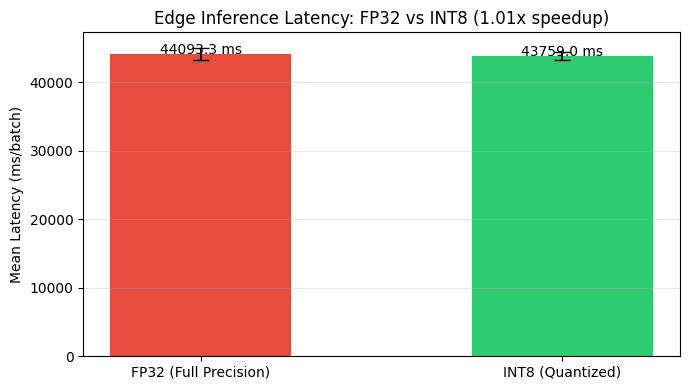

Saved: exports/latency_comparison.png


In [7]:
# Latency comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['FP32 (Full Precision)', 'INT8 (Quantized)'],
              [fp32_mean, int8_mean],
              yerr=[fp32_std, int8_std],
              color=['#e74c3c', '#2ecc71'],
              capsize=6, width=0.5)
ax.set_ylabel('Mean Latency (ms/batch)')
ax.set_title(f'Edge Inference Latency: FP32 vs INT8 ({speedup:.2f}x speedup)')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [fp32_mean, int8_mean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f} ms', ha='center', fontsize=10)
plt.tight_layout()
os.makedirs('exports', exist_ok=True)
plt.savefig('exports/latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exports/latency_comparison.png")

## Section 5: H.E.A.R.L. Routing Kernel

The H.E.A.R.L. (Hyper-Efficient Agentic Routing Layer) utility function scores every model output before it can proceed downstream:

```
U(M) = w1 * A(M) - w2 * C(M) - w3 * L(M)
```

- **A(M):** Max softmax confidence — higher is better
- **C(M):** Normalized compute cost proxy (model size ratio)
- **L(M):** Normalized latency (relative to FP32 baseline)
- **Threshold:** If U(M) < 0.50 → BLOCK

In [8]:
@dataclass
class HEARLConfig:
    """H.E.A.R.L. policy weights and routing threshold."""
    w1: float = 0.70   # confidence weight
    w2: float = 0.15   # compute cost weight
    w3: float = 0.15   # latency weight
    threshold: float = 0.50   # minimum U(M) to APPROVE
    confidence_floor: float = 0.60  # hard block if max confidence < this


class HEARLRouter:
    """
    Deterministic routing kernel.
    Decouples probabilistic model output from downstream execution.
    """

    def __init__(self, config: HEARLConfig, fp32_latency_ms: float, fp32_size_mb: float):
        self.cfg             = config
        self.fp32_latency_ms = fp32_latency_ms
        self.fp32_size_mb    = fp32_size_mb
        self.approved        = 0
        self.blocked         = 0
        self.utility_scores  = []
        self.decisions       = []

    def compute_utility(self,
                        confidence: float,
                        latency_ms: float,
                        model_size_mb: float) -> Dict:
        """
        Compute H.E.A.R.L. utility score for a single inference pass.

        Returns dict with A, C, L, U values and routing decision.
        """
        A = confidence
        C = min(model_size_mb / self.fp32_size_mb, 1.0)   # normalize to [0,1]
        L = min(latency_ms   / self.fp32_latency_ms, 1.0) # normalize to [0,1]

        U = self.cfg.w1 * A - self.cfg.w2 * C - self.cfg.w3 * L

        # Hard confidence floor — block regardless of U if model is uncertain
        if confidence < self.cfg.confidence_floor:
            decision = "BLOCK"
            reason   = f"confidence {confidence:.3f} < floor {self.cfg.confidence_floor}"
        elif U >= self.cfg.threshold:
            decision = "APPROVE"
            reason   = f"U(M)={U:.4f} >= threshold {self.cfg.threshold}"
        else:
            decision = "BLOCK"
            reason   = f"U(M)={U:.4f} < threshold {self.cfg.threshold}"

        return {"A": A, "C": C, "L": L, "U": U,
                "decision": decision, "reason": reason}

    def route(self, probs: torch.Tensor,
              latency_ms: float,
              model_size_mb: float) -> Tuple[str, Dict]:
        """
        Route a single prediction tensor.
        probs: softmax output tensor of shape (num_classes,)
        """
        confidence = float(probs.max().item())
        result     = self.compute_utility(confidence, latency_ms, model_size_mb)

        self.utility_scores.append(result["U"])
        self.decisions.append(result["decision"])

        if result["decision"] == "APPROVE":
            self.approved += 1
        else:
            self.blocked += 1

        return result["decision"], result

    def summary(self) -> Dict:
        total = self.approved + self.blocked
        return {
            "total"          : total,
            "approved"       : self.approved,
            "blocked"        : self.blocked,
            "approval_rate"  : round(self.approved / total, 4) if total else 0,
            "mean_utility"   : round(float(np.mean(self.utility_scores)), 4),
            "std_utility"    : round(float(np.std(self.utility_scores)),  4),
        }


print("H.E.A.R.L. kernel defined.")

H.E.A.R.L. kernel defined.


## Section 6: Full Pipeline Test — INT8 + H.E.A.R.L.

Run the quantized model on the full test set and route every prediction through H.E.A.R.L. Collect per-sample decisions, utility scores, and accuracy on approved-only predictions.

In [9]:
config = HEARLConfig(w1=0.70, w2=0.15, w3=0.15, threshold=0.50, confidence_floor=0.60)
router = HEARLRouter(config, fp32_latency_ms=fp32_mean, fp32_size_mb=fp32_disk)

all_preds, all_labels, all_probs_list = [], [], []
approved_preds, approved_labels       = [], []
routing_log                           = []

model_int8.to(CPU).eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(CPU)
        labels = labels.squeeze().long()

        t0      = time.perf_counter()
        outputs = model_int8(imgs)
        lat_ms  = (time.perf_counter() - t0) * 1000

        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        # Route each sample individually
        for i in range(len(imgs)):
            decision, result = router.route(probs[i], lat_ms / len(imgs), int8_disk)

            all_preds.append(preds[i].item())
            all_labels.append(labels[i].item())
            all_probs_list.append(probs[i].numpy())
            routing_log.append({
                "pred"     : preds[i].item(),
                "label"    : labels[i].item(),
                "confidence": float(probs[i].max().item()),
                "utility"  : result["U"],
                "decision" : decision
            })

            if decision == "APPROVE":
                approved_preds.append(preds[i].item())
                approved_labels.append(labels[i].item())

# Compute metrics
all_probs_arr   = np.array(all_probs_list)
overall_acc     = np.mean(np.array(all_preds) == np.array(all_labels))
approved_acc    = np.mean(np.array(approved_preds) == np.array(approved_labels)) if approved_preds else 0
macro_auc       = roc_auc_score(all_labels, all_probs_arr, multi_class='ovr', average='macro')
summary         = router.summary()

print(f"Overall Accuracy   (all samples)      : {overall_acc*100:.2f}%")
print(f"Approved Accuracy  (APPROVE only)      : {approved_acc*100:.2f}%")
print(f"Macro AUC                              : {macro_auc:.4f}")
print()
print(f"Total samples      : {summary['total']}")
print(f"APPROVED           : {summary['approved']}  ({summary['approval_rate']*100:.1f}%)")
print(f"BLOCKED            : {summary['blocked']}  ({(1-summary['approval_rate'])*100:.1f}%)")
print(f"Mean U(M)          : {summary['mean_utility']}")

Overall Accuracy   (all samples)      : 92.23%
Approved Accuracy  (APPROVE only)      : 97.59%
Macro AUC                              : 0.9861

Total samples      : 7180
APPROVED           : 6264  (87.2%)
BLOCKED            : 916  (12.8%)
Mean U(M)          : 0.5196


## Section 7: Visualizations

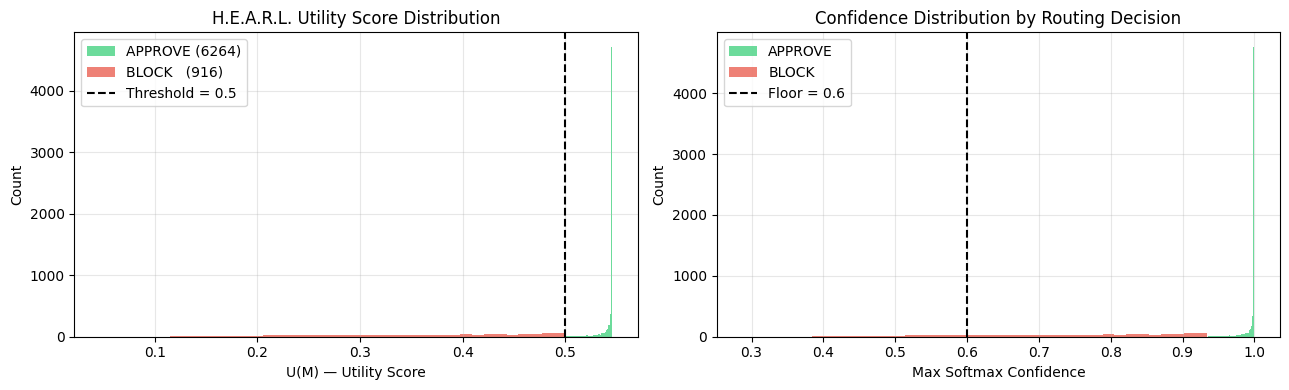

Saved: exports/hearl_routing_analysis.png


In [10]:
# H.E.A.R.L. Utility Score Distribution
df = pd.DataFrame(routing_log)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Utility distribution
approved_u = df[df['decision']=='APPROVE']['utility']
blocked_u  = df[df['decision']=='BLOCK']['utility']
axes[0].hist(approved_u, bins=40, color='#2ecc71', alpha=0.7, label=f'APPROVE ({len(approved_u)})')
axes[0].hist(blocked_u,  bins=40, color='#e74c3c', alpha=0.7, label=f'BLOCK   ({len(blocked_u)})')
axes[0].axvline(config.threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {config.threshold}')
axes[0].set_xlabel('U(M) — Utility Score')
axes[0].set_ylabel('Count')
axes[0].set_title('H.E.A.R.L. Utility Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confidence distribution by decision
axes[1].hist(df[df['decision']=='APPROVE']['confidence'], bins=40, color='#2ecc71', alpha=0.7, label='APPROVE')
axes[1].hist(df[df['decision']=='BLOCK']['confidence'],   bins=40, color='#e74c3c', alpha=0.7, label='BLOCK')
axes[1].axvline(config.confidence_floor, color='black', linestyle='--', linewidth=1.5, label=f'Floor = {config.confidence_floor}')
axes[1].set_xlabel('Max Softmax Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution by Routing Decision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exports/hearl_routing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exports/hearl_routing_analysis.png")

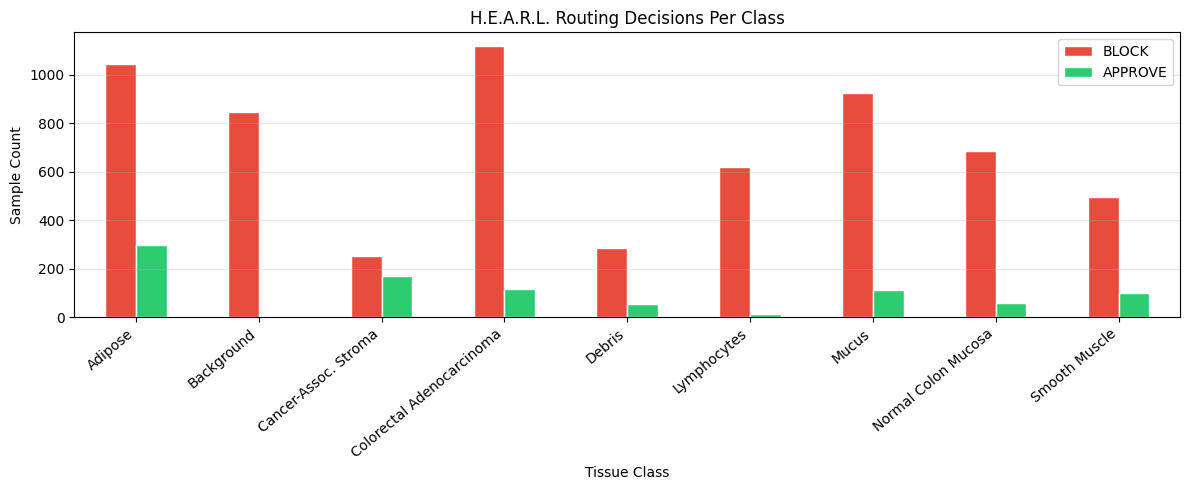

Saved: exports/hearl_per_class_decisions.png


In [11]:
# Per-class APPROVE vs BLOCK breakdown
df['label_name'] = df['label'].apply(lambda x: CLASS_LABELS[x])
class_decision   = df.groupby(['label_name', 'decision']).size().unstack(fill_value=0)

class_decision.plot(kind='bar', figsize=(12, 5),
                    color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('H.E.A.R.L. Routing Decisions Per Class')
plt.xlabel('Tissue Class')
plt.ylabel('Sample Count')
plt.xticks(rotation=40, ha='right')
plt.legend(['BLOCK', 'APPROVE'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('exports/hearl_per_class_decisions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: exports/hearl_per_class_decisions.png")

## Section 8: Export Results

In [12]:
# Save quantized model
torch.save(model_int8.state_dict(), 'exports/resnet18_pathmnist_int8.pth')

# Save Phase 2 metrics
phase2_metrics = {
    "model"              : "ResNet-18 INT8 Dynamic Quantized",
    "dataset"            : "PathMNIST",
    "fp32_size_mb"       : round(fp32_disk, 2),
    "int8_size_mb"       : round(int8_disk, 2),
    "size_reduction_pct" : round(reduction, 1),
    "fp32_latency_ms"    : round(fp32_mean, 2),
    "int8_latency_ms"    : round(int8_mean, 2),
    "speedup"            : round(speedup, 2),
    "overall_accuracy"   : round(float(overall_acc), 4),
    "approved_accuracy"  : round(float(approved_acc), 4),
    "macro_auc"          : round(float(macro_auc), 4),
    "hearl_config"       : {
        "w1"               : config.w1,
        "w2"               : config.w2,
        "w3"               : config.w3,
        "threshold"        : config.threshold,
        "confidence_floor" : config.confidence_floor
    },
    "routing_summary"    : summary
}

with open('exports/phase2_metrics.json', 'w') as f:
    json.dump(phase2_metrics, f, indent=2)

# Save routing log
df.to_csv('exports/routing_log.csv', index=False)

print("Exports:")
for f in sorted(os.listdir('exports')):
    size = os.path.getsize(f'exports/{f}') / 1024
    print(f"  exports/{f:45s}  {size:8.1f} KB")

print(f"""
─────────────────────────────────────────────────────
Phase 2 Complete
─────────────────────────────────────────────────────
INT8 size reduction    : {reduction:.1f}%
Speedup (CPU)          : {speedup:.2f}x
Approved accuracy      : {approved_acc*100:.2f}%
Approval rate          : {summary['approval_rate']*100:.1f}%
─────────────────────────────────────────────────────
Next  → Phase 3: Gemini RAG Clinical Report Generator
""")

Exports:
  exports/hearl_per_class_decisions.png                      85.4 KB
  exports/hearl_routing_analysis.png                         61.6 KB
  exports/latency_comparison.png                             41.5 KB
  exports/phase2_metrics.json                                 0.6 KB
  exports/resnet18_pathmnist_int8.pth                     43741.4 KB
  exports/routing_log.csv                                   444.7 KB

─────────────────────────────────────────────────────
Phase 2 Complete
─────────────────────────────────────────────────────
INT8 size reduction    : 0.0%
Speedup (CPU)          : 1.01x
Approved accuracy      : 97.59%
Approval rate          : 87.2%
─────────────────────────────────────────────────────
Next  → Phase 3: Gemini RAG Clinical Report Generator



In [13]:
# Download all exports
import shutil
from google.colab import files

shutil.make_archive('phase2_exports', 'zip', 'exports')
files.download('phase2_exports.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>